# 0 - Quick Imports

In [1]:
import numpy as np
import PIL
from PIL import Image
import numpy as np
import torch
import os
import sys

sys.path.append('..')
os.chdir('..')
print(os.getcwd()) # confirm the working directory is the repo root

# Some more magic so that the notebook will reload external python modules;
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2

/scratch3/zha439/project/alphagen/negtome


In [2]:
def display_alongside_batch(img_list, resize_dims=(512,512)):
    if isinstance(resize_dims, int):
        resize_dims = (resize_dims,resize_dims)
    res = np.concatenate([np.array(img.resize(resize_dims)) for img in img_list], axis=1)
    return Image.fromarray(res)

#  1 - SDXL + NegToMe

In [3]:
from src.negtome.pipeline_negtome_sdxl import StableDiffusionXLNegToMePipeline
pipe = StableDiffusionXLNegToMePipeline.from_pretrained("SG161222/RealVisXL_V4.0", torch_dtype=torch.float16)
pipe = pipe.to("cuda:1")

/scratch3/zha439/env/negtome/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading pipeline components...: 100%|████████████████████████████████████████████| 7/7 [00:10<00:00,  1.43s/it]


done ... updated attn processors


using prompt: a hyper-realistic digital painting of a person

use_negtome: False


100%|██████████████████████████████████████████████████████████████████████████| 50/50 [00:18<00:00,  2.73it/s]


use_negtome: False
Time taken: 20.11 seconds


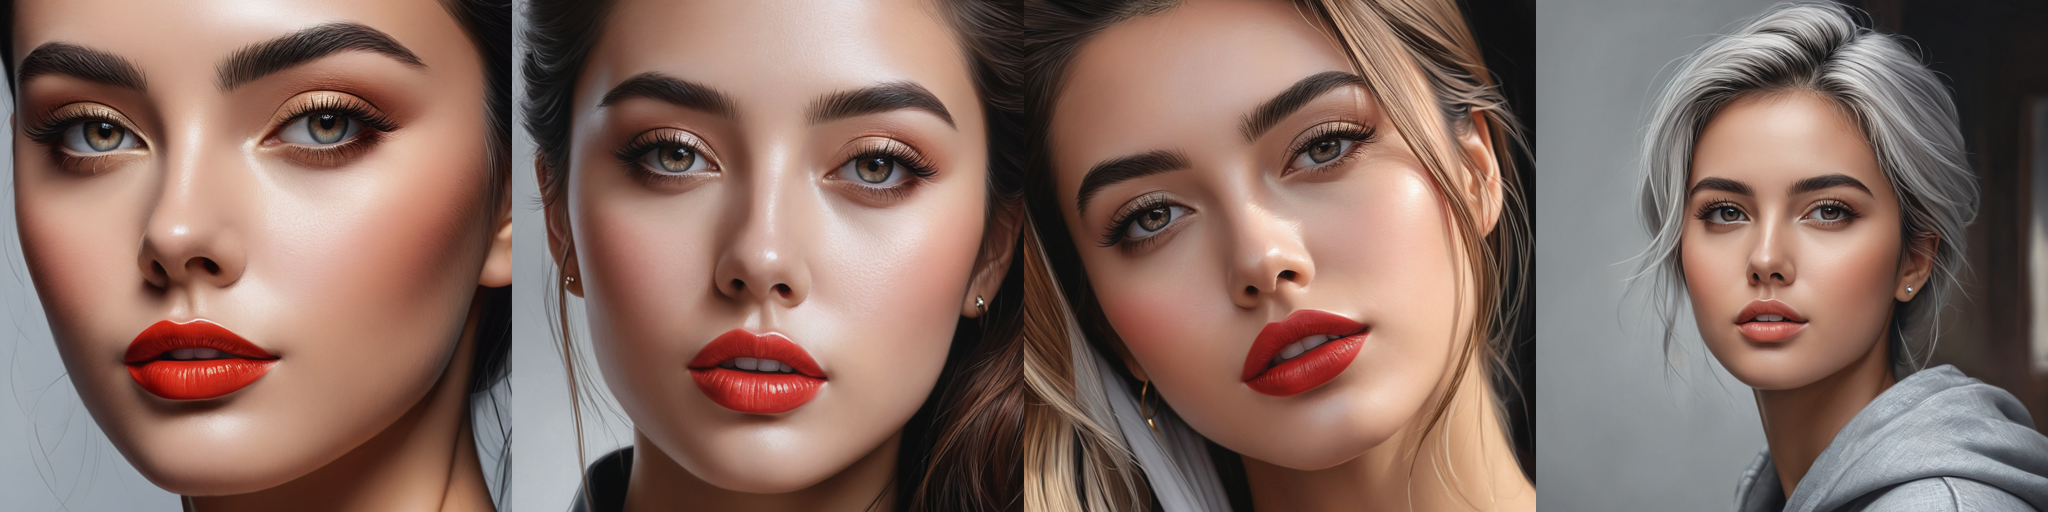


use_negtome: True


100%|██████████████████████████████████████████████████████████████████████████| 50/50 [00:19<00:00,  2.56it/s]


use_negtome: True
Time taken: 21.09 seconds


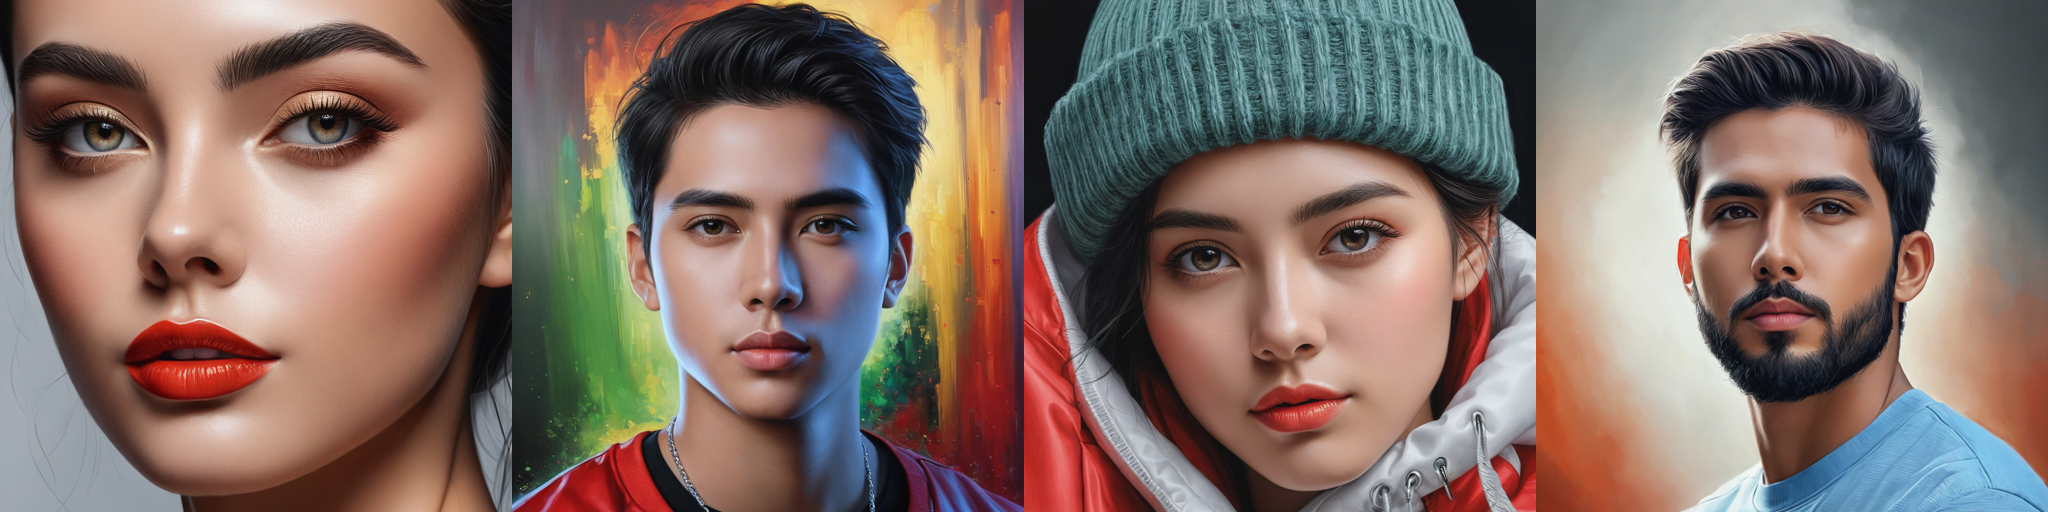


Percentage increase in inference time with negtome: 4.91%


In [26]:
# from diffusers.utils import logging
# logging.set_verbosity_debug()  # only show errors not warnings: https://huggingface.co/docs/diffusers/en/api/logging
import time

negtome_args = {
    'use_negtome': False,
    'merging_alpha': 1.9, #controls diversity: higher alpha pushes images further apart
    'merging_threshold': 0.7, #controls which features are pushed apart: higher threshold preserves original features more
    'merging_dropout': 0.,
    'merging_t_start': 1000,
    'merging_t_end': 900,
}

# input prompt 
prompt = "a hyper-realistic digital painting of a woman"
prompt = "a hyper-realistic digital painting of a building"
prompt = "a 3D animation of a cat"
prompt = "a hyper-realistic digital painting of a person"

# prompt = "a high resolution photo of a child"
# prompt = "a high resolution photo of a child"
# prompt = "a high resolution photo of a child eating an apple"

# prompt = "A panda leaping up to catch a dumpling mid-air with its paws, surrounded by bamboo and a few steaming baskets of dumplings on the ground"
print (f"using prompt: {prompt}")

# hyperparameters
seed = 0 
num_inference_steps = 50
num_images_per_prompt = 4 # generate 4 images across the batch
height = width = 1024 
neg_prompt = "naked, deformed, bad anatomy, disfigured, poorly drawn face, mutation, extra limb, ugly, disgusting, poorly drawn hands, missing limb, floating limbs, disconnected limbs, blurry, watermarks, oversaturated, distorted hands, amputation"

# generate both with and w/o negtome
inference_times = []
for use_negtome in [False, True][-2:]:
    print(f"\nuse_negtome: {use_negtome}")
    generator = torch.Generator(pipe.device).manual_seed(seed)
    
    # Measure time
    start_time = time.time()
    images = pipe(
        prompt=prompt,
        guidance_scale=5.0,
        height=height,
        width=width,
        num_inference_steps=num_inference_steps,
        generator=generator,
        num_images_per_prompt=num_images_per_prompt,
        negative_prompt=neg_prompt,
        use_negtome=use_negtome,
        negtome_args=negtome_args,
    ).images
    elapsed_time = time.time() - start_time
    inference_times.append(elapsed_time)
    
    print(f"use_negtome: {use_negtome}\nTime taken: {elapsed_time:.2f} seconds")
    display(display_alongside_batch(images, resize_dims=512))

# Calculate percentage increase
percentage_increase = ((inference_times[1] - inference_times[0]) / inference_times[0]) * 100
print(f"\nPercentage increase in inference time with negtome: {percentage_increase:.2f}%")

In [ ]:
display(display_alongside_batch(images, resize_dims=512))

## With CADs

- https://arxiv.org/pdf/2310.17347 
 - https://github.com/v0xie/sd-webui-cads/blob/main/scripts/cads.py#L166


use_cads: False


100%|██████████████████████████████████████████████████████████████████████████| 50/50 [00:08<00:00,  5.82it/s]


use_cads: False
Time taken: 9.67 seconds


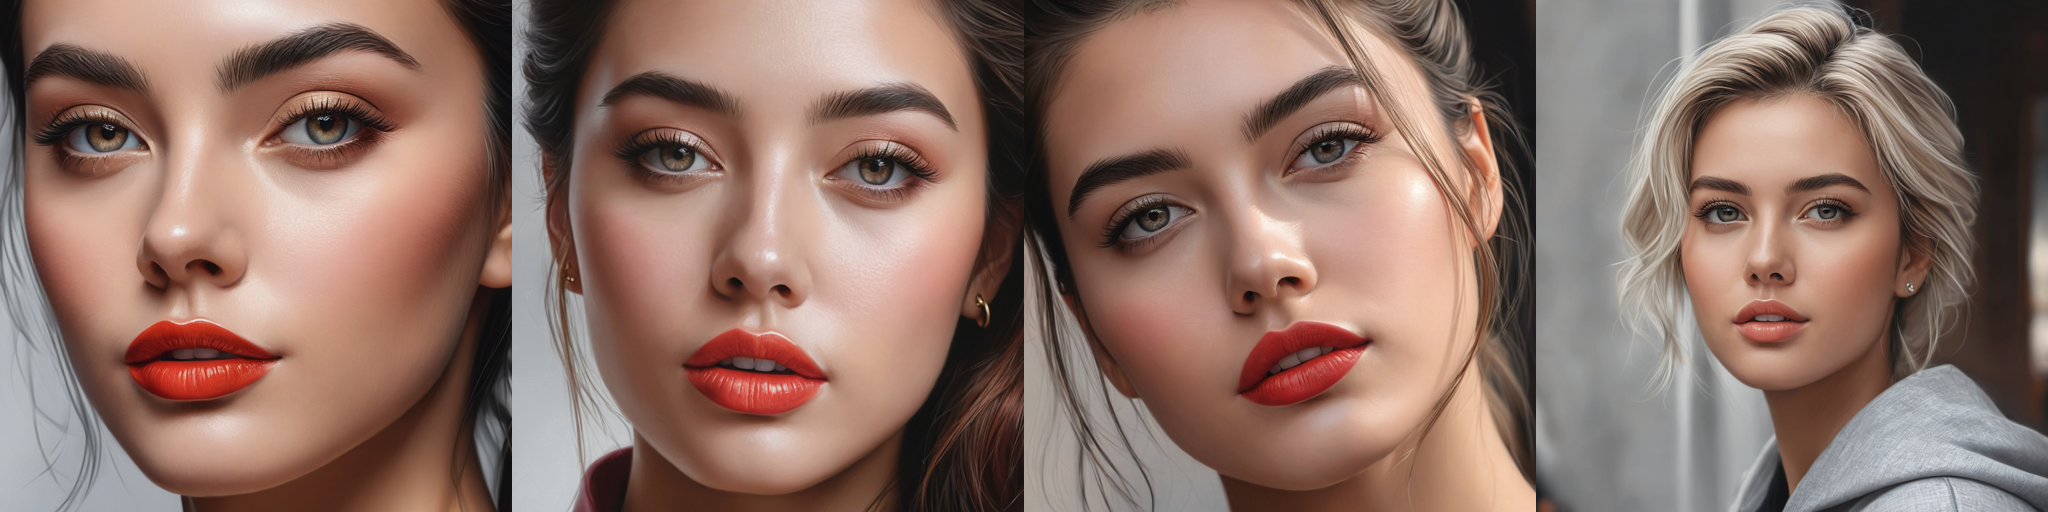


use_cads: True


100%|██████████████████████████████████████████████████████████████████████████| 50/50 [00:08<00:00,  5.67it/s]


use_cads: True
Time taken: 9.56 seconds


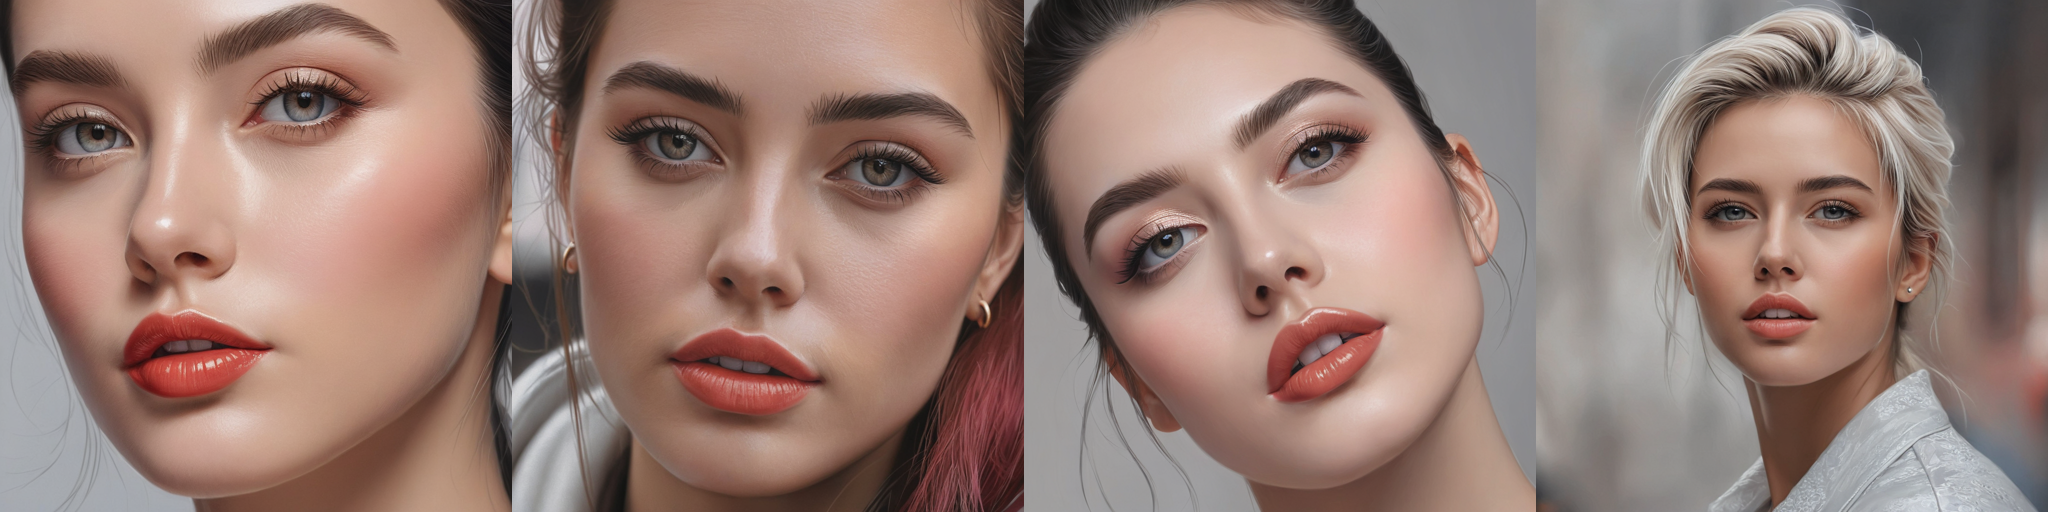


Percentage increase in inference time with CADS: -1.15%


In [25]:
import time

# Example CADS parameters (tweak as desired)
cads_args = {
    "use_cads": False,            # The pipeline code uses either `use_cads` or cads_args["use_cads"]
    "tau1": 0.6,                 # t-end
    "tau2": 0.9,                 # t-start
    "noise_scale": 0.25,         # Scale of noise injected
    "mixing_factor": 1.0,        # 1.0 => fully re-normalize after adding noise, 0.0 => no renormalization
    "rescale": True,             # Whether to do that renormalization
}

# Example prompt and config
prompt = "a hyper-realistic digital painting of a woman"
prompt = "a hyper-realistic digital painting of a building"
prompt = "a 3D animation of a cat"
prompt = "a hyper-realistic digital painting of a person"

neg_prompt = "naked, deformed, bad anatomy, disfigured, poorly drawn face, missing limb, floating limbs, watermarks, oversaturated"

seed = 0
num_inference_steps = 50
num_images_per_prompt = 4
height = width = 1024

inference_times = []
for use_cads in [False, True][:]:
    print(f"\nuse_cads: {use_cads}")
    generator = torch.Generator(pipe.device).manual_seed(seed)

    start_time = time.time()
    images = pipe(
        prompt=prompt,
        guidance_scale=5.0,
        height=height,
        width=width,
        num_inference_steps=num_inference_steps,
        generator=generator,
        num_images_per_prompt=num_images_per_prompt,
        negative_prompt=neg_prompt,
        use_cads=use_cads,            # <--- passes in the toggle
        cads_args=cads_args,         # <--- passes in hyperparams
    ).images
    elapsed_time = time.time() - start_time
    inference_times.append(elapsed_time)

    print(f"use_cads: {use_cads}\nTime taken: {elapsed_time:.2f} seconds")
    display(display_alongside_batch(images, resize_dims=512))

# Calculate percentage increase
percentage_increase = ((inference_times[1] - inference_times[0]) / inference_times[0]) * 100
print(f"\nPercentage increase in inference time with CADS: {percentage_increase:.2f}%")

In [ ]:
display(display_alongside_batch(images, resize_dims=512))